### ```🧾 Step 1: Problem Understanding```
📌 Problem Statement

Credit card fraud has become a major challenge for banks and financial institutions. Fraudulent transactions cause significant financial losses and reduce customer trust.

The objective of this project is to build a Machine Learning model that can accurately identify fraudulent credit card transactions while minimizing false alarms.

🎯 Business Objective

Develop a fraud detection system that can classify each credit card transaction as either:

Legitimate Transaction (Class = 0)
Fraudulent Transaction (Class = 1)

The model should detect as many fraud cases as possible while minimizing incorrect fraud predictions.

🎯 Machine Learning Problem

This is a:

✅ Supervised Learning

Because the target label is already available.

It is also a:

✅ Binary Classification Problem

Since there are only two possible classes.

### ```🚀 Step 2: Data Understanding```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../Data/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
from IPython.display import display
import pandas as pd

print('='*60)
print('📊 EXPLORATORY DATA ANALYSIS (EDA) SUMMARY')
print('='*60)

print('\n📌 Dataset Shape')
print(df.shape)

print('\n📌 First 5 Rows')
display(df.head())

print('\n📌 Last 5 Rows')
display(df.tail())

print('\n📌 Random Sample')
display(df.sample(5))

print('\n📌 Column Names')
display(pd.DataFrame(df.columns, columns=['Columns']))

print('\n📌 Data Types')
display(df.dtypes.to_frame('Data Type'))

print('\n📌 Dataset Information')
df.info()

print('\n📌 Missing Values')
display(df.isnull().sum().to_frame('Missing Values'))

print('\n📌 Duplicate Rows')
print(df.duplicated().sum())

print('\n📌 Numerical Summary')
display(df.describe().T)


print('\n📌 Correlation Matrix')
display(df.corr(numeric_only=True))


📊 EXPLORATORY DATA ANALYSIS (EDA) SUMMARY

📌 Dataset Shape
(284807, 31)

📌 First 5 Rows


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



📌 Last 5 Rows


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0



📌 Random Sample


...

,Missing Values
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0



📌 Duplicate Rows
1081

📌 Numerical Summary


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995



📌 Correlation Matrix


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447
V5,0.173072,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,...,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.386356,-0.094974
V6,-0.063016,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,...,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,0.215981,-0.043643
V7,0.084714,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,...,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,0.397311,-0.187257
V8,-0.036949,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,...,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,-0.103079,0.019875
V9,-0.008660,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,...,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.044246,-0.097733


 ```Target Variable Distribution```

In [5]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
(df["Class"].value_counts(normalize=True) * 100).round(3)

Class
0    99.827
1     0.173
Name: proportion, dtype: float64

### ```Dataset Overview```

- Total Records: 284,807
- Total Features: 31
- Target Variable: Class
- Missing Values: 0
- Duplicate Records: 0

### ```Feature Description```
```
Time → Time elapsed (in seconds) from the first transaction.
Amount → Transaction amount.
V1–V28 → PCA-transformed features (original feature names hidden for privacy).
Class → Target variable:
0 = Genuine Transaction
1 = Fraud Transaction
```

Observation

The dataset is extremely imbalanced, with fraudulent transactions representing only 0.173% of all transactions. Because of this, accuracy is not an appropriate evaluation metric, and metrics such as Precision, Recall, F1-Score, and ROC-AUC will be more informative.

### ``` EDA - Step 1: Class Distribution```

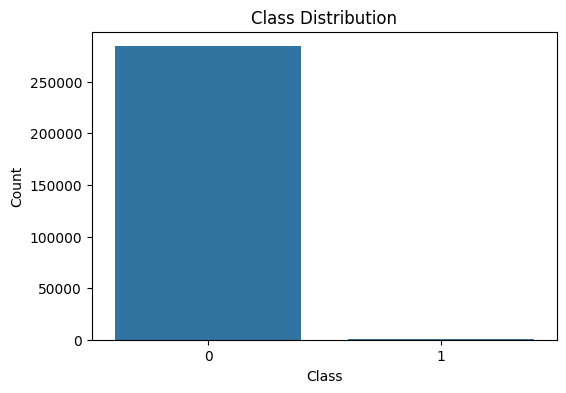

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

### ```2: Percentage Distribution (Pie Chart)```

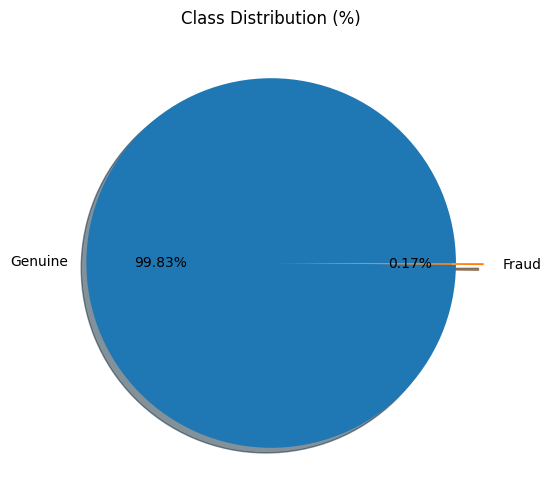

In [8]:
plt.figure(figsize=(6,6))

df["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    labels=["Genuine","Fraud"],
    explode=[0,0.15],
    shadow=True
)

plt.ylabel("")
plt.title("Class Distribution (%)")

plt.show()

### ```Step 3: Amount Distribution```

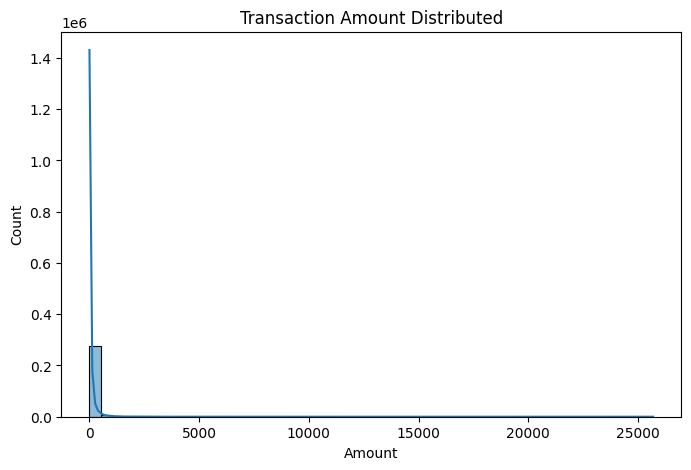

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'],bins=50,kde=True)
plt.title("Transaction Amount Distributed")
plt.xlabel("Amount")
plt.show()

### ```Step 4: Time Distribution```

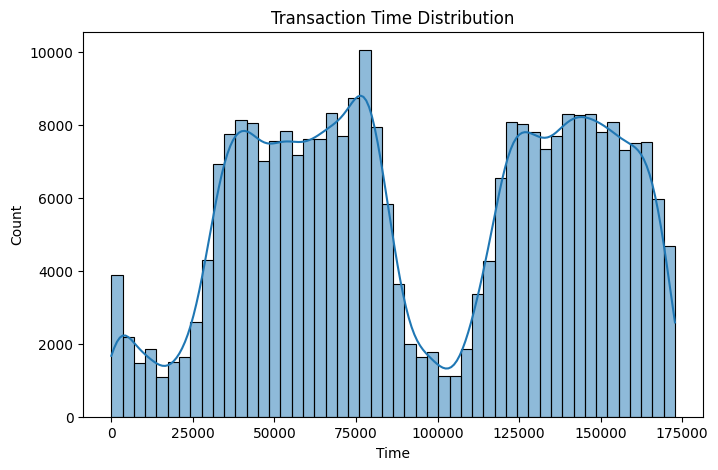

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Time"], bins=50, kde=True)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.show()

### ```Step 5: Amount vs Class```

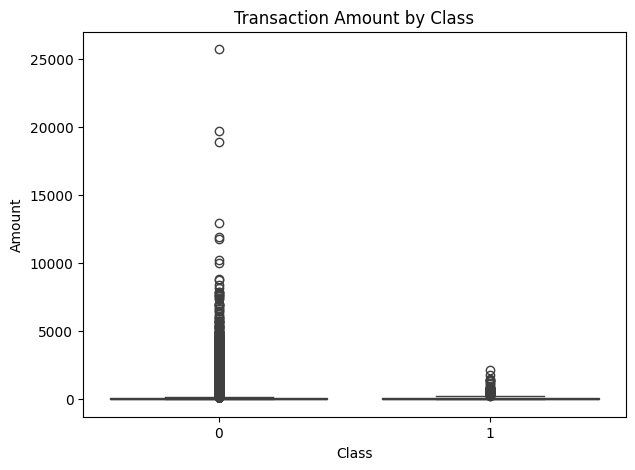

In [19]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")

plt.show()

### ```Step 6: Time vs Class```

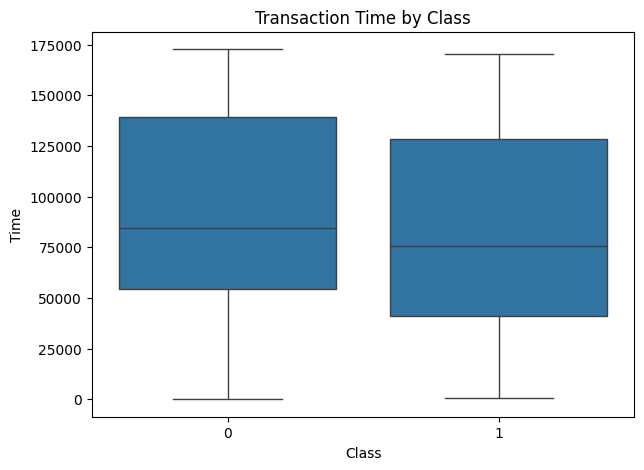

In [20]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Class", y="Time", data=df)

plt.title("Transaction Time by Class")

plt.show()

### ```Step 7: Correlation with Target```

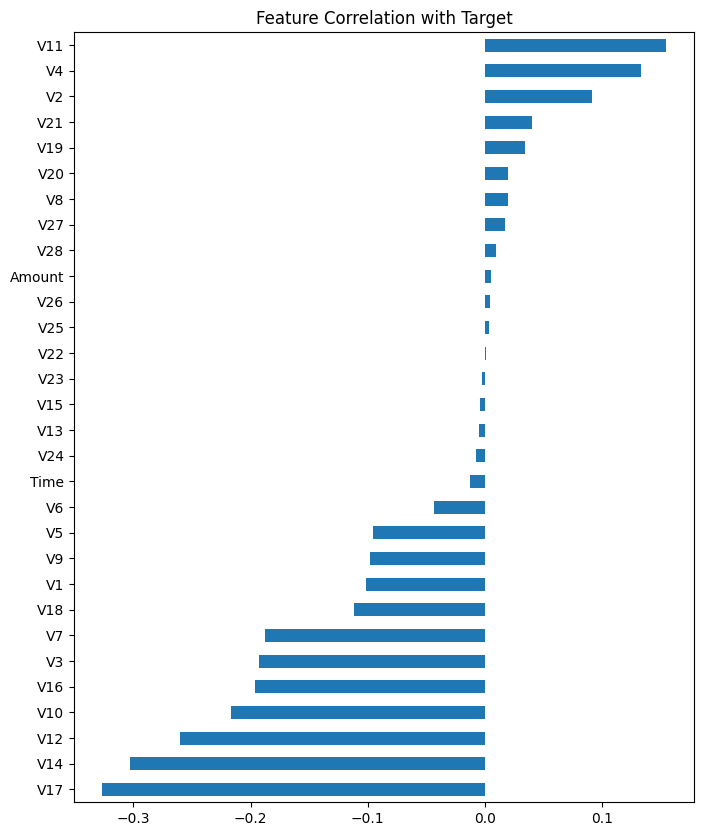

In [21]:
corr = df.corr()["Class"].sort_values()

plt.figure(figsize=(8,10))

corr.drop("Class").plot(kind="barh")

plt.title("Feature Correlation with Target")

plt.show()

### ```Step 8: Amount Statistics by Class```

In [22]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


### ``` Model Building```

```1: Feature & Target```

In [23]:
X = df.drop("Class", axis=1)
y = df["Class"]

```Step 2: Train-Test Split```

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [25]:
print("Train:")
print(y_train.value_counts())

print("\nTest:")
print(y_test.value_counts())

Train:
Class
0    227451
1       394
Name: count, dtype: int64

Test:
Class
0    56864
1       98
Name: count, dtype: int64


```3: Scaling```

V1–V28 pehle hi PCA ke baad standardized hain.

Sirf Time aur Amount ko scale karna hai.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ("scale",StandardScaler(),['Time',"Amount"])
    ],
    remainder="passthrough"
)

In [27]:
## Train DAta
X_train = preprocessor.fit_transform(X_train)
## Test Data
X_test = preprocessor.transform(X_test)

In [28]:
print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


### ```Baseline Model 1: Logistic Regression (Without SMOTE) ```

scene ye hai ki dataset imbalanced hai , ham phle jo base model hai haamra logistic regression usko try kr rhe hai as hai dkene ke liye kya accuracy nikl krayega kya socre rhega with SMOTE

In [30]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
)
lr.fit(X_train,y_train)

y_pred =lr.predict(X_test)

In [31]:
y_prob = lr.predict_proba(X_test)[:, 1]

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, confusion_matrix, classification_report

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))

print('\nConfusion Matrix')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report')
print(classification_report(y_test, y_pred))

print('\ROC AUV SCORE')
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9991573329588147
Precision: 0.8289473684210527
Recall   : 0.6428571428571429
F1 Score : 0.7241379310344828

Confusion Matrix
[[56851    13]
 [   35    63]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

\ROC AUV SCORE
ROC AUC  : 0.9558983554029378


```Model 2: Random Forest (Without SMOTE)```

In [35]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))

print('\nConfusion Matrix')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report')
print(classification_report(y_test, y_pred))

Accuracy : 0.9996137776061234
Precision: 0.9418604651162791
Recall   : 0.826530612244898
F1 Score : 0.8804347826086957

Confusion Matrix
[[56859     5]
 [   17    81]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



```Model 3: Decision Tree (Without SMOTE)```

In [39]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9991046662687406
Precision: 0.7422680412371134
Recall   : 0.7346938775510204
F1 Score : 0.7384615384615385
ROC AUC  : 0.8671271160405637

Confusion Matrix
[[56839    25]
 [   26    72]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.73      0.74        98

    accuracy                           1.00     56962
   macro avg       0.87      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [42]:
## INSTALL SMOTE
# ! pip install imbalanced-learn

In [43]:
## IMPORT
from imblearn.over_sampling import SMOTE

```Step 3: Apply SMOTE (⚠️ Only Training Data)```

In [44]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [48]:
print("Before SMOTE ",y_train.value_counts())
print("--"*60)
print("AFTER APPLY SOMTE",y_train_smote.value_counts())

Before SMOTE  Class
0    227451
1       394
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
AFTER APPLY SOMTE Class
0    227451
1    227451
Name: count, dtype: int64


Class
0    227451
1    227451
Name: count, dtype: int64


### ```Step 5: Train Random Forest Again(with Smote)```

In [51]:
from sklearn.ensemble import RandomForestClassifier
rf_smote= RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    n_jobs=-1

)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred = rf_smote.predict(X_test)


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))

print('\nConfusion Matrix')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report')
print(classification_report(y_test, y_pred))

Accuracy : 0.9994557775359011
Precision: 0.8526315789473684
Recall   : 0.826530612244898
F1 Score : 0.8393782383419689

Confusion Matrix
[[56850    14]
 [   17    81]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



```Logistic Regression + SMOTE```

In [55]:

lr_smote= LogisticRegression(
    random_state=42,
    max_iter=1000,

)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred = lr_smote.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1 Score :', f1_score(y_test, y_pred))

print('\nConfusion Matrix')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report')
print(classification_report(y_test, y_pred))

Accuracy : 0.9742108774270566
Precision: 0.058027079303675046
Recall   : 0.9183673469387755
F1 Score : 0.1091570648878108

Confusion Matrix
[[55403  1461]
 [    8    90]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



```Decision Tree + SMOTE```

In [56]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_smote, y_train_smote)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9970331097924933
Precision: 0.34080717488789236
Recall   : 0.7755102040816326
F1 Score : 0.4735202492211838
ROC AUC  : 0.8864625443593306

Confusion Matrix
[[56717   147]
 [   22    76]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.34      0.78      0.47        98

    accuracy                           1.00     56962
   macro avg       0.67      0.89      0.74     56962
weighted avg       1.00      1.00      1.00     56962



## ``` best Model:```
```Random Forest Without SMOTE ```

### ``` Hyperparameter Tuning```

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100,200,300],
    "max_depth": [None,10,20,30],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt","log2"]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,          # Sirf 20 combinations
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

# Final Model Selection

Six experiments were conducted:

- Logistic Regression (Without SMOTE)
- Logistic Regression (With SMOTE)
- Decision Tree (Without SMOTE)
- Decision Tree (With SMOTE)
- Random Forest (Without SMOTE)
- Random Forest (With SMOTE)

Among all the models, the Random Forest trained on the original dataset (without SMOTE) achieved the best overall performance.

Although SMOTE improved Recall for some models, it also introduced a large number of False Positives, which significantly reduced Precision and F1-score.

For Random Forest, SMOTE did not improve Recall, while Precision decreased due to an increase in False Positives.

Therefore, the baseline Random Forest model was selected for Hyperparameter Tuning because it provided the best balance between Precision, Recall, F1-score, and overall business performance.

```Next Step: Feature Importance```

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

## Feature Importance

Random Forest provides feature importance scores that indicate the contribution of each feature in predicting fraudulent transactions.

The top-ranked features contribute the most to the model's decision-making process, while lower-ranked features have relatively less influence.

Since the original features were transformed using PCA (V1–V28), the importance scores identify influential components rather than the original transaction attributes.